<a href="https://colab.research.google.com/github/Maricielo-Gomez/Lenguajes-de-programacion/blob/main/TendenciaGoogle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANÁLISIS DE LA TENDENCIA DEL PRECIO DE LAS ACCIONES DE GOOGLE (GOOGL)

## 1. Introducción
- Planteamiento de la pregunta central:  
  **¿El precio de Google ha mostrado tendencia creciente en el tiempo?**


## 2. ¿Qué es un Ticker?

Un **ticker** es el código que representa una empresa en la bolsa.  


El ticker de Google es:

---
| **Empresa / Índice**           | **Ticker** | **Descripción**                                   |
| ------------------------------ | ---------- | ------------------------------------------------- |
| Alphabet Inc. (Google)                     | `GOOGL`     | Matriz de Google                  |

---

## 3. Preparar el Entorno

Antes de escribir código, vamos a **instalar las librerías necesarias**:
- `yfinance` → para traer datos de Yahoo Finance
- `plotly` → para graficar los datos de manera interactiva

In [1]:
# Instalación de librerías
!pip install yfinance plotly

In [2]:
# Importación de librerías
import yfinance as yf
import plotly.express as px

print("Librerías cargadas correctamente ✅")


Librerías cargadas correctamente ✅


---

## 4. Recolección de datos con yfinance

Para analizar la tendencia del precio de Google, necesitamos extraer información histórica.  
La librería `yfinance` nos permite hacerlo de forma sencilla.

### 4.1. Creación del objeto
Un **ticker** es el código que representa a una empresa en la bolsa.  
En el caso de Google, el ticker es `GOOGL`.

Cuando usamos `yfinance`, creamos un objeto que contiene toda la información de esa empresa:

```python
google = yf.Ticker("GOOGL")



### 4.2. Funciones más útiles para el análisis:

| Función / Método           | Para qué sirve                                 | Ejemplo |
|-----------------------------|-----------------------------------------------|---------|
| `yf.Ticker("GOOGL")`       | Crea un objeto con toda la información de Google | `google = yf.Ticker("GOOGL")` |
| `.history(period="5y")`    | Descarga precios históricos (ej. últimos 5 años) | `google.history(period="5y")` |
| `.info`                    | Información general de la empresa              | `google.info` |



💡 **Tip:** Para responder nuestra pregunta central (¿El precio de Google ha mostrado tendencia creciente?), el método más importante es .history(), porque nos devuelve los precios de cierre diarios


## 4.3. Extracción de datos históricos de Google

Con el objeto `google = yf.Ticker("GOOGL")` usamos el método `.history()` para obtener precios de apertura, cierre, máximos, mínimos y volumen.  
En este caso descargamos los últimos **5 años**, base para analizar la tendencia.


In [14]:
google = yf.Ticker("GOOGL")
data = google.history(period="5y")["Close"]
data.head()

,Close
Date,
2020-09-16 00:00:00-04:00,75.086624
2020-09-17 00:00:00-04:00,73.842697
2020-09-18 00:00:00-04:00,72.057503
2020-09-21 00:00:00-04:00,71.017189
2020-09-22 00:00:00-04:00,72.491020


## 5: Análisis de la estabilidad y tendencia del precio de Google

### 5.1. Importación de las librerías

Se utilizan yfinance para descargar los datos, pandas para manipulación y matplotlib para visualización.

In [38]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 5.2. Cálculo de estadísticos básicos

Se calcula la media y la desviación estándar del precio de cierre:

In [18]:
media = data.mean()
desv = data.std()
print(f"Media del precio de cierre: {media:.2f} USD")
print(f"Desviación estándar: {desv:.2f} USD")

Media del precio de cierre: 133.88 USD
Desviación estándar: 32.72 USD


### 5.3. Evaluación de la volatilidad



In [30]:
if desv < 10:
    print("La acción es estable")
else:
    print("La acción es volátil📈📉")


La acción es volátil📈📉


### 5.4. Visualización de la tendencia del precio de Google
A continuación veremos cómo ha evolucionado el precio de cierre de Google a lo largo de los últimos 5 años.

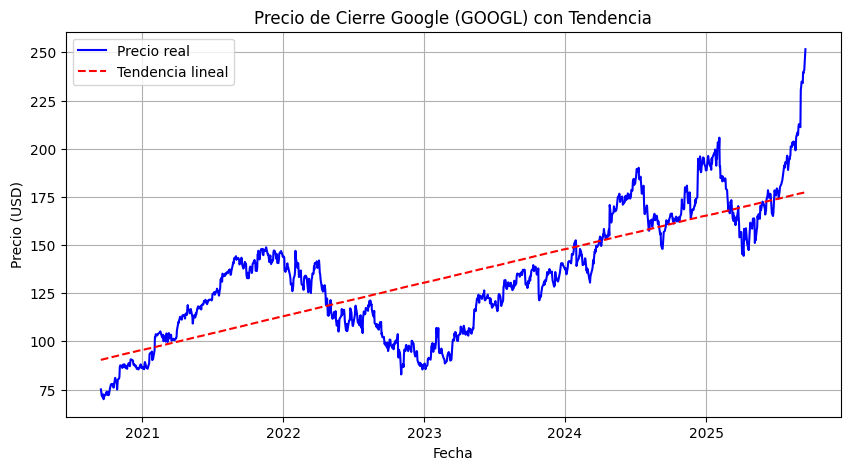

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Convertir a DataFrame y resetear índice
df = data.reset_index()  # 'Date' pasa a columna
df['Days'] = np.arange(len(df))  # número de días
X = df[['Days']]  # variable independiente
y = df['Close']   # variable dependiente

# Ajustar regresión lineal
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)  # predicciones de la tendencia

# Graficar precios reales y tendencia
plt.figure(figsize=(10,5))
plt.plot(df['Date'], y, label='Precio real', color='blue')
plt.plot(df['Date'], y_pred, label='Tendencia lineal', color='red', linestyle='--')
plt.title("Precio de Cierre Google (GOOGL) con Tendencia")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.grid(True)
plt.legend()
plt.show()
